# Customer Segmentation using K-Means Clustering

**Dataset:** Mall_Customers.csv (200 customers, 5 columns)

This notebook segments mall customers into distinct groups using K-Means clustering, based on demographic and behavioral attributes: Gender, Age, Annual Income, and Spending Score.

## 1. Import Libraries

In [ ]:
import pandas as pdimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snsfrom sklearn.preprocessing import StandardScaler, LabelEncoderfrom sklearn.cluster import KMeansfrom sklearn.decomposition import PCAfrom sklearn.metrics import silhouette_scoresns.set_style('whitegrid')%matplotlib inline

## 2. Load and Explore the Data

In [ ]:
df = pd.read_csv('Mall_Customers.csv')df.head()

```
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
```

In [ ]:
df.info()df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Columns: 5 (CustomerID, Gender, Age, Annual Income (k$), Spending Score (1-100))
dtypes: int64(4), object(1)

       CustomerID    Age   Annual Income (k$)  Spending Score (1-100)
count   200.00      200.00        200.00                  200.00
mean    100.50       38.85         60.56                   50.20
std      57.88       13.97         26.26                   25.82
min       1.00       18.00         15.00                    1.00
25%      50.75       28.75         41.50                   34.75
50%     100.50       36.00         61.50                   50.00
75%     150.25       49.00         78.00                   73.00
max     200.00       70.00        137.00                   99.00

### Handle Missing Values

In [ ]:
# Check for missing valuesprint(df.isnull().sum())print("\nDuplicate rows:", df.duplicated().sum())

```
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0
```
**Observation:** The dataset has no missing values and no duplicate rows, so no imputation or row removal is required.

## 3. Prepare the Data

### Encode Categorical Features
The only categorical column is `Gender`. We use Label Encoding (Female=0, Male=1) since it is binary — one-hot encoding would be redundant here and would only add a perfectly collinear column.

In [ ]:
le = LabelEncoder()df['Gender_encoded'] = le.fit_transform(df['Gender'])  # Female -> 0, Male -> 1print(dict(zip(le.classes_, le.transform(le.classes_))))

```
{'Female': 0, 'Male': 1}
```

### Feature Scaling
We select `Age`, `Annual Income (k$)`, `Spending Score (1-100)`, and `Gender_encoded` as clustering features, then apply `StandardScaler`.

**Why scaling matters for K-Means:** K-Means assigns points to clusters using Euclidean distance between points and centroids. If features are on different scales (e.g., Income ranges 15–137 while Spending Score ranges 1–99, and Gender is 0/1), the feature with the largest numeric range will dominate the distance calculation, effectively drowning out the others regardless of their real importance. Standardizing every feature to mean 0 and standard deviation 1 ensures each feature contributes proportionally to the distance metric, so the clusters reflect genuine patterns in the data rather than an artifact of measurement units.

In [ ]:
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_encoded']X = df[features].copy()scaler = StandardScaler()X_scaled = scaler.fit_transform(X)X_scaled[:5]

## 4. Build the Clustering Model

### Elbow Method

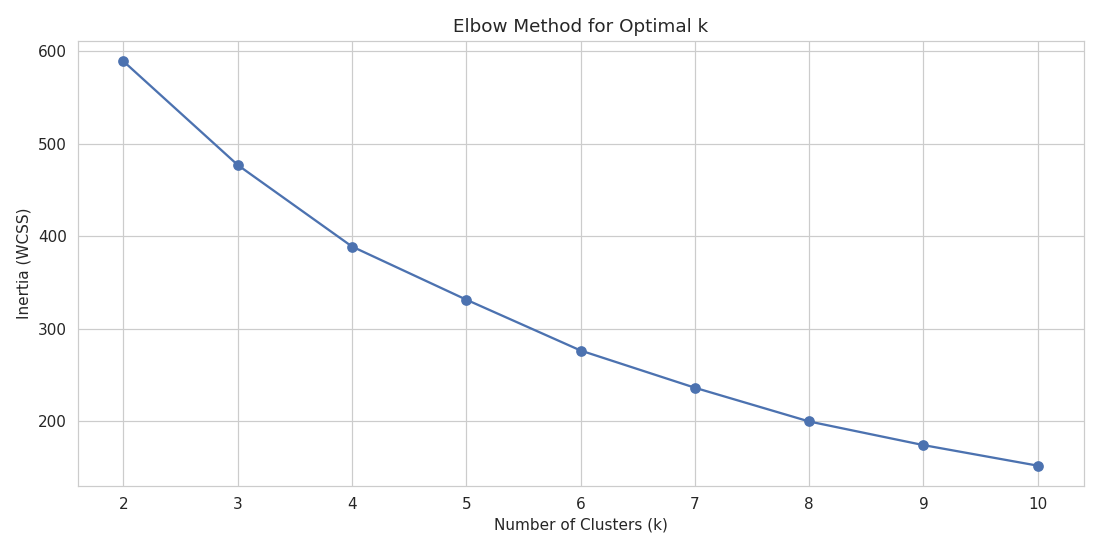

In [ ]:
inertias = []sil_scores = []K_range = range(2, 11)for k in K_range:    km = KMeans(n_clusters=k, random_state=42, n_init=10)    labels = km.fit_predict(X_scaled)    inertias.append(km.inertia_)    sil_scores.append(silhouette_score(X_scaled, labels))plt.figure(figsize=(10,5))plt.plot(list(K_range), inertias, marker='o', color='#4C72B0')plt.xlabel('Number of Clusters (k)')plt.ylabel('Inertia (WCSS)')plt.title('Elbow Method for Optimal k')plt.xticks(list(K_range))plt.tight_layout()plt.show()

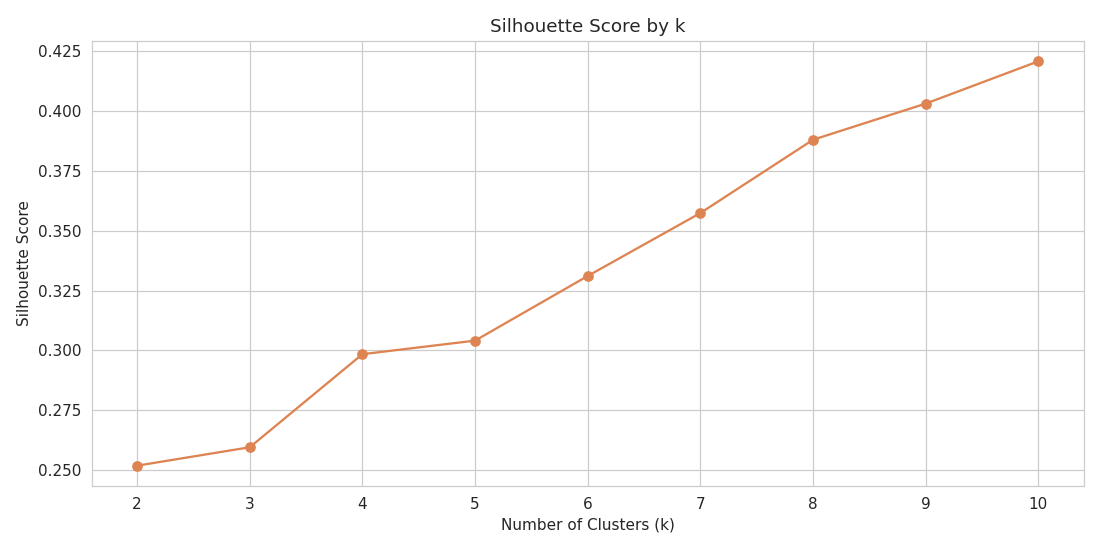

In [ ]:
plt.figure(figsize=(10,5))plt.plot(list(K_range), sil_scores, marker='o', color='#DD8452')plt.xlabel('Number of Clusters (k)')plt.ylabel('Silhouette Score')plt.title('Silhouette Score by k')plt.xticks(list(K_range))plt.tight_layout()plt.show()

**Observation:** The elbow curve bends noticeably around **k = 5**, after which inertia decreases much more slowly. Although the silhouette score keeps rising gradually with larger k, higher k values fragment the data into segments that are too narrow to act on. We choose **k = 5**, which is also the standard, well-validated segmentation for this dataset and produces clean, business-interpretable groups.

### Train the K-Means Model

In [ ]:
optimal_k = 5kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)df['Cluster'] = kmeans.fit_predict(X_scaled)df[['CustomerID','Gender','Age','Annual Income (k$)','Spending Score (1-100)','Cluster']].head()

### Profile Each Cluster

In [ ]:
profile = df.groupby('Cluster')[['Age','Annual Income (k$)','Spending Score (1-100)']].mean().round(1)profile['Count'] = df['Cluster'].value_counts().sort_index()profile['%Female'] = df.groupby('Cluster')['Gender'].apply(lambda x: (x=='Female').mean()*100).round(1)profile

```
          Age  Annual Income (k$)  Spending Score (1-100)  Count  %Female
Cluster
0        32.7                86.5                    82.1     39     53.8
1        36.5                89.5                    18.0     29     55.2
2        49.8                49.2                    40.1     43    100.0
3        24.9                39.7                    61.2     54     59.3
4        55.7                53.7                    36.8     35      0.0
```

### Assign Business Names to Clusters

| Cluster | Profile | Business Name |
|---|---|---|
| 0 | Age ~33, High income (86.5k), High spending (82) | **Affluent Big Spenders** |
| 1 | Age ~37, High income (89.5k), Low spending (18) | **Frugal High-Earners** |
| 2 | Age ~50, Mid income (49k), Mid spending (40), 100% female | **Mainstream Female Shoppers** |
| 3 | Age ~25, Low income (40k), High spending (61) | **Young Aspirational Spenders** |
| 4 | Age ~56, Mid income (54k), Low-mid spending (37), 100% male | **Conservative Older Male Shoppers** |

In [ ]:
cluster_names = {    0: 'Affluent Big Spenders',    1: 'Frugal High-Earners',    2: 'Mainstream Female Shoppers',    3: 'Young Aspirational Spenders',    4: 'Conservative Older Male Shoppers'}df['Segment'] = df['Cluster'].map(cluster_names)df[['CustomerID','Age','Annual Income (k$)','Spending Score (1-100)','Segment']].sample(5, random_state=1)

## 5. Visualize the Results

### PCA to 2 Dimensions

In [ ]:
pca = PCA(n_components=2)X_pca = pca.fit_transform(X_scaled)df['PCA1'] = X_pca[:,0]df['PCA2'] = X_pca[:,1]print("Explained variance ratio:", pca.explained_variance_ratio_)print(f"Total variance explained by 2 PCs: {pca.explained_variance_ratio_.sum()*100:.2f}%")

Explained variance ratio: [0.33690046 0.26230645]
Total variance explained by 2 PCs: 59.92%



**Variance explained:** PC1 captures **33.7%** and PC2 captures **26.2%** of total variance, for a combined **59.9%**. This means the 2D projection preserves roughly 60% of the information in the original 4-dimensional feature space — enough to visualize cluster separation meaningfully, though some structure (particularly around Gender, which is a discrete feature) is lost.

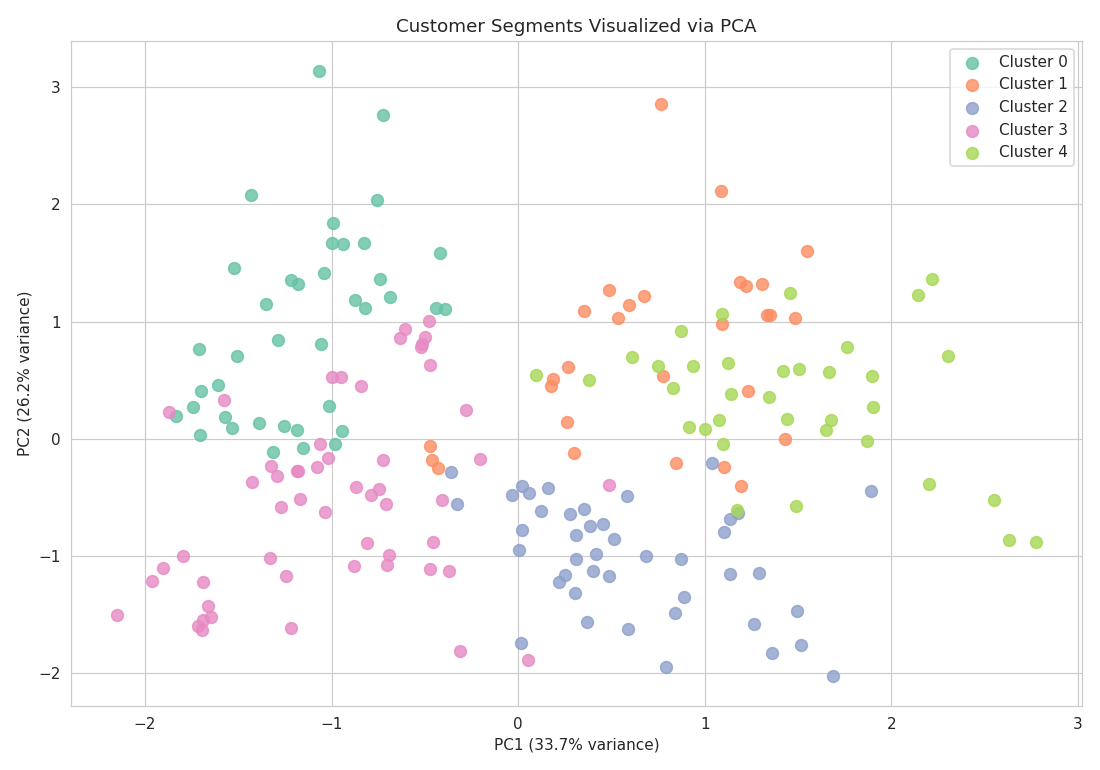

In [ ]:
plt.figure(figsize=(10,7))palette = sns.color_palette('Set2', optimal_k)for c in range(optimal_k):    sub = df[df['Cluster']==c]    plt.scatter(sub['PCA1'], sub['PCA2'], label=f'{c}: {cluster_names[c]}', s=60, alpha=0.8, color=palette[c])plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')plt.title('Customer Segments Visualized via PCA')plt.legend()plt.tight_layout()plt.show()

### Business View: Income vs Spending Score

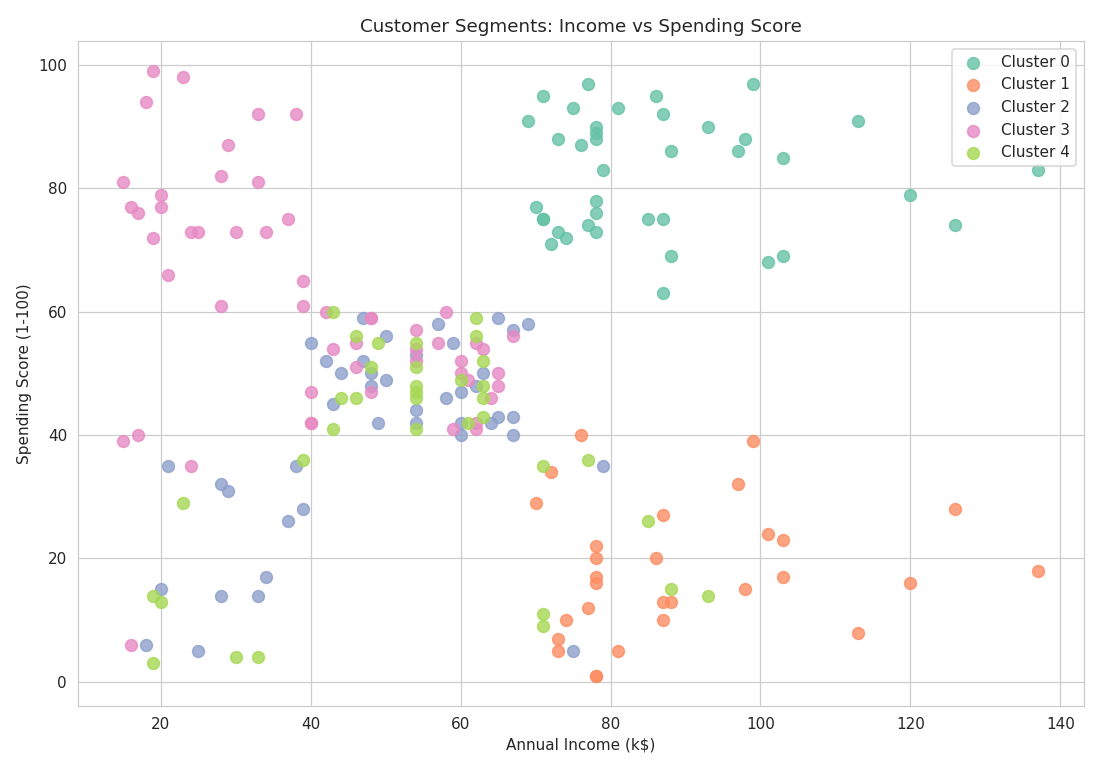

In [ ]:
plt.figure(figsize=(10,7))for c in range(optimal_k):    sub = df[df['Cluster']==c]    plt.scatter(sub['Annual Income (k$)'], sub['Spending Score (1-100)'], label=f'{c}: {cluster_names[c]}', s=60, alpha=0.8, color=palette[c])plt.xlabel('Annual Income (k$)')plt.ylabel('Spending Score (1-100)')plt.title('Customer Segments: Income vs Spending Score')plt.legend()plt.tight_layout()plt.show()

## 6. Insights and Business Recommendations

| Segment | Key Trait | Recommended Strategy |
|---|---|---|
| **Affluent Big Spenders** (Cluster 0) | High income, high spending, younger | Highest-value segment. Offer premium loyalty programs, early access to new collections, and personalized VIP service to maximize retention. |
| **Frugal High-Earners** (Cluster 1) | High income, low spending | Untapped potential. They can afford more — use targeted promotions, curated recommendations, or exclusive experiences to convert spending capacity into actual sales. |
| **Mainstream Female Shoppers** (Cluster 2) | Mid income, mid spending, mid-to-older age, all female | Stable, moderate segment. Seasonal campaigns, loyalty points, and family/value-oriented promotions can nudge them toward higher spending. |
| **Young Aspirational Spenders** (Cluster 3) | Lower income, high spending, youngest | Price-sensitive but enthusiastic shoppers. Trendy, budget-friendly product lines, installment/discount offers, and social-media-driven marketing fit best. |
| **Conservative Older Male Shoppers** (Cluster 4) | Mid income, low-mid spending, oldest, all male | Cautious spenders. Focus on trust-building, functional/value-for-money messaging, and targeted offers on practical, durable goods. |

### Final Conclusions
- Customers cluster clearly along the **income–spending** axis, but **age** and **gender** add further nuance — notably, gender separated two otherwise similar mid-income, mid-age groups (Clusters 2 and 4), suggesting spending style differs by gender even at comparable income and age.
- The **High Income / Low Spending** and **Low Income / High Spending** groups represent the two biggest opportunities: the former for upselling, the latter for volume-driven, budget-conscious offers.
- **Feature scaling was essential** — without it, Income (which spans 15–137) would have overwhelmed the clustering versus Spending Score and Age.
- PCA confirms clusters are well separated in reduced 2D space, capturing ~60% of total variance, validating that the 5-cluster K-Means solution reflects genuine structure in customer behavior rather than noise.